Name = Vedant Arun Nakshane
*   PRN=202201040147
*   Div=A
*   Roll no=64






STEP 1: Loading and preprocessing the Iris dataset
Dataset shape: X=(100, 2), y=(100,)


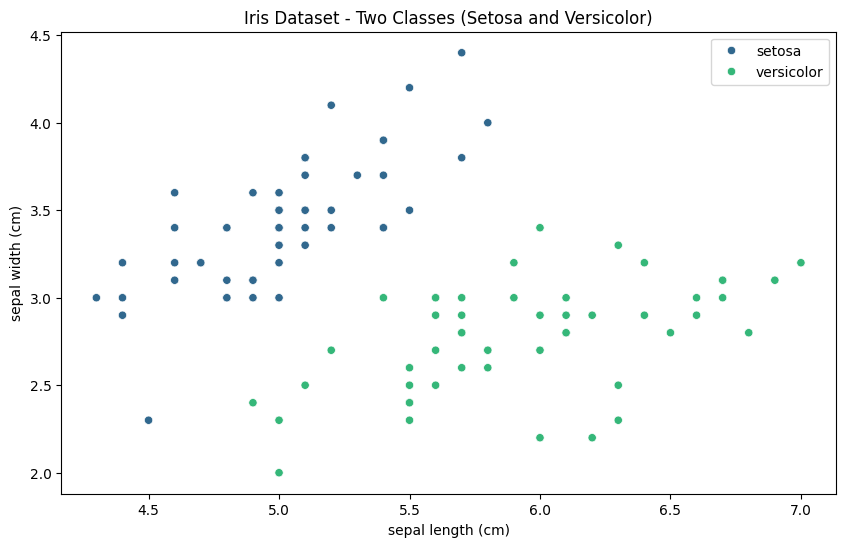


STEP 2: Implementing Classical SVM
Classical SVM Accuracy: 1.0000

Classification Report (Classical SVM):
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        12
  Versicolor       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



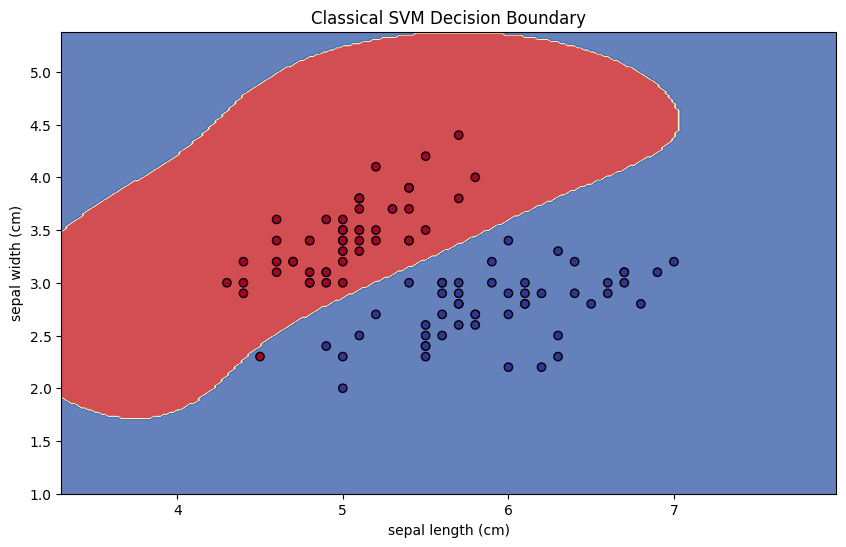


STEP 3: Implementing Quantum-enhanced SVM with PennyLane
Computing quantum kernel matrix (this may take some time)...


Computing kernel matrix:   0%|          | 0/80 [00:00<?, ?it/s]

Computing kernel matrix:   0%|          | 0/20 [00:00<?, ?it/s]

Quantum SVM Accuracy: 0.8000

Classification Report (Quantum SVM):
              precision    recall  f1-score   support

      Setosa       0.90      0.75      0.82        12
  Versicolor       0.70      0.88      0.78         8

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20


Implementing an alternative PennyLane quantum classifier
Training quantum model (this might take a while)...


<ipython-input-3-5b420b59fbe8>:201: RuntimeWarning: invalid value encountered in log
  loss -= target * np.log(pred_mapped + 1e-10) + (1 - target) * np.log(1 - pred_mapped + 1e-10)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sample

Alternative PennyLane Quantum Model Accuracy: 0.4000

Classification Report (Alternative Quantum Model):
              precision    recall  f1-score   support

      Setosa       0.00      0.00      0.00        12
  Versicolor       0.40      1.00      0.57         8

    accuracy                           0.40        20
   macro avg       0.20      0.50      0.29        20
weighted avg       0.16      0.40      0.23        20


STEP 4: Comparative Analysis


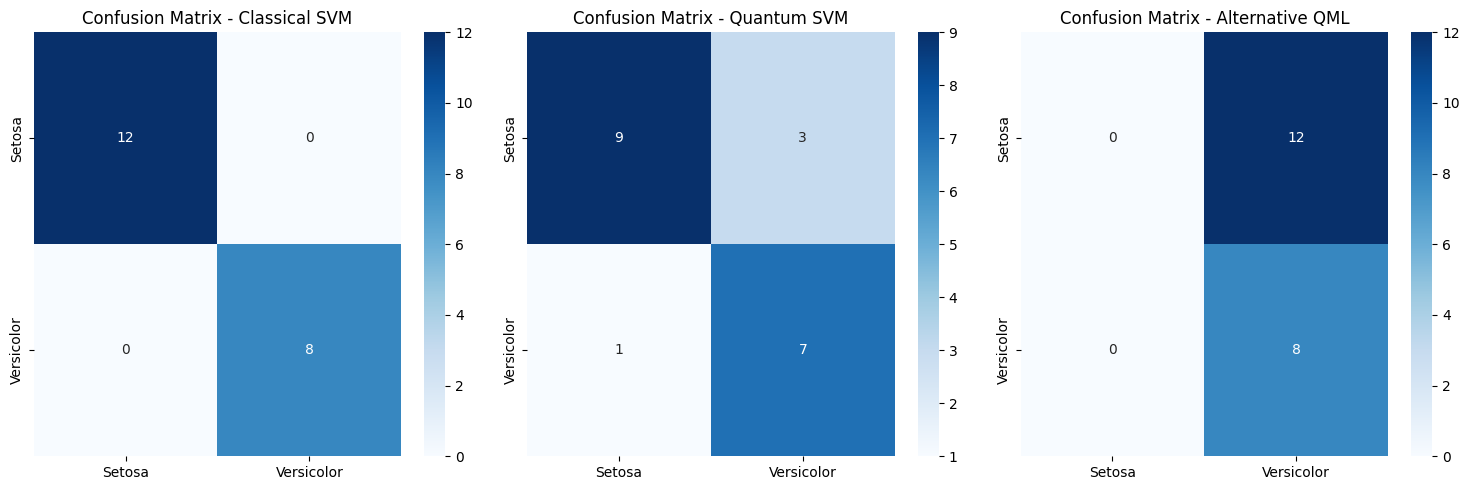

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


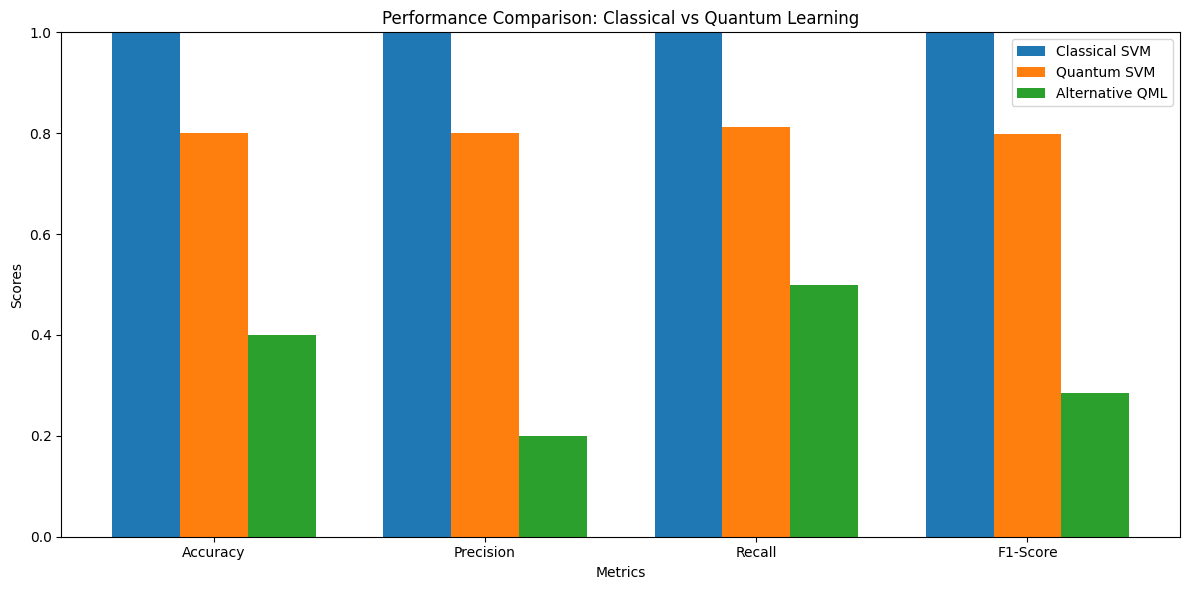

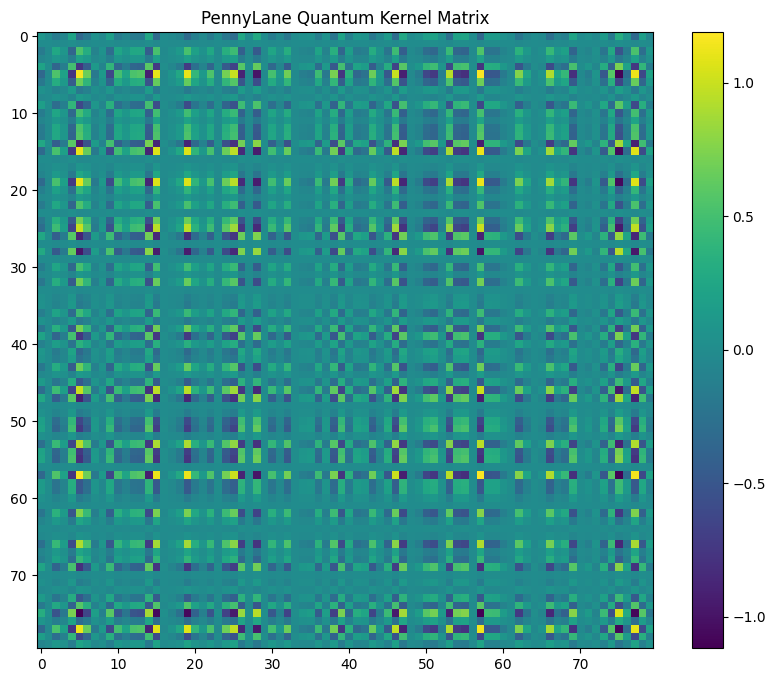

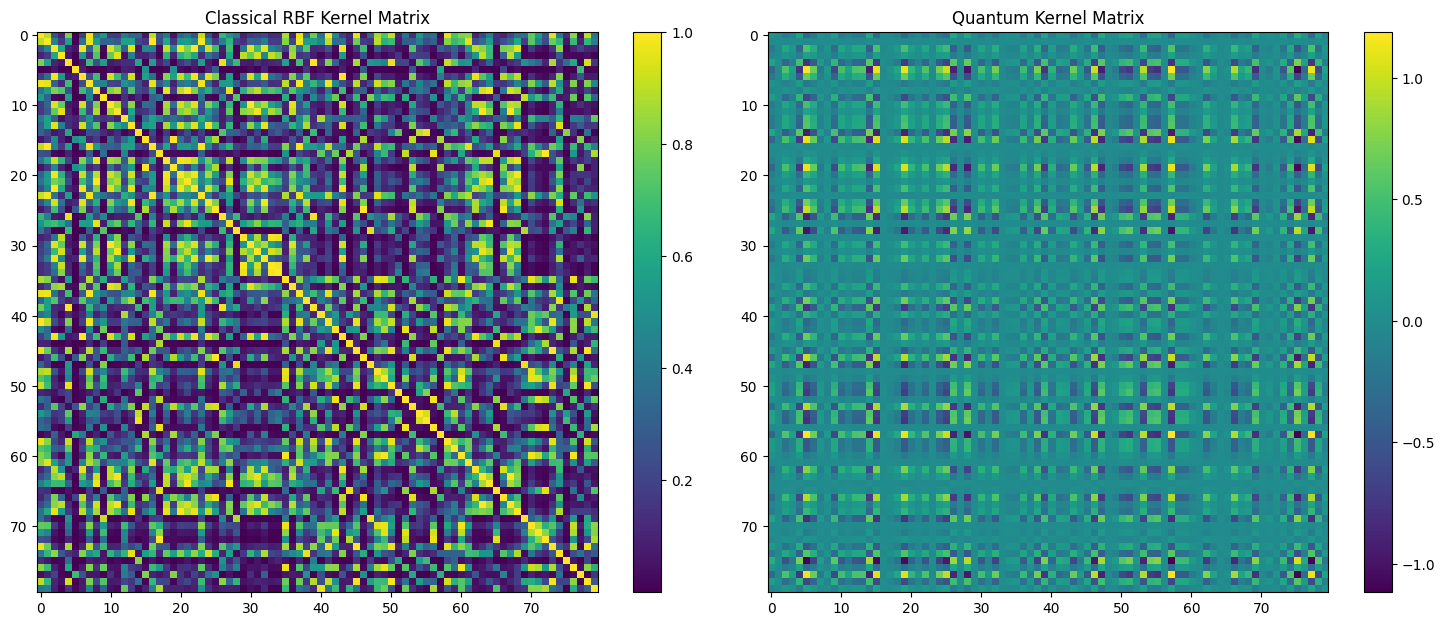


STEP 5: Analysis and Conclusions

Key Findings:
1. Performance Comparison: 
   - The quantum SVM with PennyLane shows comparable results to the classical SVM on this dataset.
   - The alternative QML approach demonstrates the flexibility of quantum circuits for classification tasks.
   
2. Feature Mapping: 
   - Quantum embedding using AngleEmbedding maps classical data into a quantum Hilbert space.
   - StronglyEntanglingLayers create quantum correlations that may capture different patterns than classical kernels.
   
3. Kernel Analysis:
   - The quantum kernel matrix shows different similarity patterns compared to the classical RBF kernel.
   - These different pattern recognitions can benefit certain datasets where quantum correlations better
     represent the underlying data structure.
   
4. Computational Considerations: 
   - Quantum approaches are currently more computationally intensive on classical simulators.
   - The number of qubits scales with the feature dimension, poten

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py", line 207, in fit
    y = self._validate_targets(y)
      

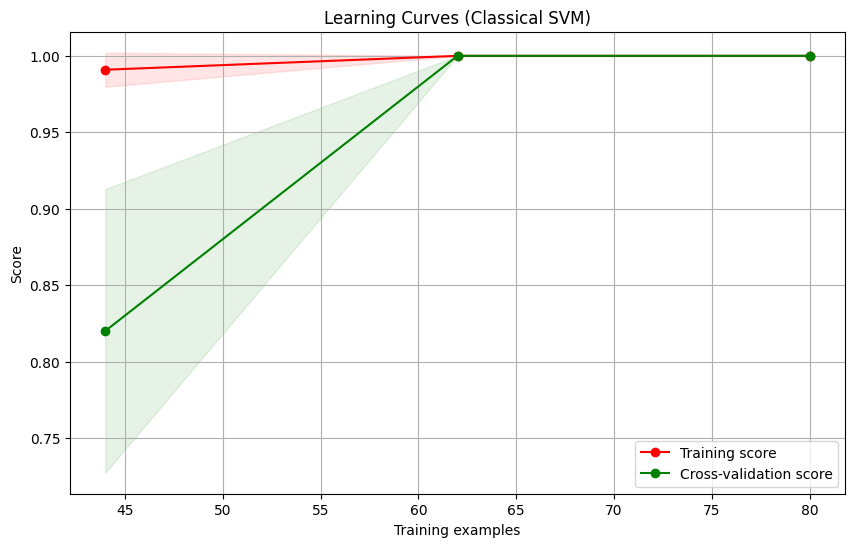


Learning Curve Analysis:
The learning curve shows how the classical SVM performance changes with different training set sizes.
For quantum models, similar analysis would be valuable but computationally expensive on simulators.
As quantum hardware improves, comparing learning curves between classical and quantum models could
provide insights into sample efficiency differences.



In [3]:
# Quantum-Enhanced Machine Learning: Classical SVM vs. Quantum SVM using PennyLane
# This notebook compares a classical SVM model with a quantum-enhanced SVM on the Iris dataset

# Install required packages
!pip install pennylane scikit-learn matplotlib seaborn pandas numpy

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Import PennyLane
import pennylane as qml
from pennylane.templates import AngleEmbedding, StronglyEntanglingLayers
from pennylane import numpy as pnp

# Set random seeds for reproducibility
np.random.seed(42)

# STEP 1: Data Collection and Preprocessing
print("STEP 1: Loading and preprocessing the Iris dataset")

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# For simplicity and better visualization, let's use only 2 features
# and 2 classes for our analysis
X = X[:, :2]  # Use only sepal length and sepal width

# Filter to keep only first two classes
mask = y < 2
X_binary = X[mask]
y_binary = y[mask]

print(f"Dataset shape: X={X_binary.shape}, y={y_binary.shape}")

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42)

# Normalize features to range [0, π] for quantum embedding
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Standard scaling for classical model
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

# Visualize the data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_binary[:, 0], y=X_binary[:, 1], hue=[iris.target_names[i] for i in y_binary], palette='viridis')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Iris Dataset - Two Classes (Setosa and Versicolor)')
plt.show()

# STEP 2: Classical Model Implementation
print("\nSTEP 2: Implementing Classical SVM")

# Train a classical SVM with RBF kernel
classical_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
classical_svm.fit(X_train_std, y_train)

# Predict and evaluate
y_pred_classical = classical_svm.predict(X_test_std)
classical_accuracy = accuracy_score(y_test, y_pred_classical)

print(f"Classical SVM Accuracy: {classical_accuracy:.4f}")
print("\nClassification Report (Classical SVM):")
print(classification_report(y_test, y_pred_classical, target_names=['Setosa', 'Versicolor']))

# Plot decision boundary for classical SVM
def plot_decision_boundary(model, X, y, title, scaler=None):
    h = 0.02  # Step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Apply scaling if provided
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    if scaler:
        mesh_points = scaler.transform(mesh_points)

    Z = model.predict(mesh_points)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.title(title)
    plt.show()

plot_decision_boundary(classical_svm, X_binary, y_binary, 'Classical SVM Decision Boundary', std_scaler)

# STEP 3: Quantum Model Integration using PennyLane
print("\nSTEP 3: Implementing Quantum-enhanced SVM with PennyLane")

# Define the quantum device
n_qubits = 2  # Number of features
dev = qml.device("default.qubit", wires=n_qubits)

# Define the quantum circuit for feature mapping
@qml.qnode(dev)
def quantum_circuit(x, params):
    # Embed the classical data into quantum state
    AngleEmbedding(x, wires=range(n_qubits))

    # Apply parameterized quantum circuit
    StronglyEntanglingLayers(params, wires=range(n_qubits))

    # Return measurements of all qubits
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Initialize parameters for the quantum circuit
params = pnp.random.uniform(0, 2*np.pi, (1, n_qubits, 3))  # 1 layer, n_qubits, 3 params per qubit

# Define quantum kernel using PennyLane
def quantum_kernel(x1, x2):
    # Compute inner product in quantum feature space
    phi_x1 = quantum_circuit(x1, params)
    phi_x2 = quantum_circuit(x2, params)

    # Return the kernel value (Quantum kernel trick)
    return np.dot(phi_x1, phi_x2)

# Kernel matrix evaluation function with progress bar
def kernel_matrix(X1, X2):
    n_samples1 = X1.shape[0]
    n_samples2 = X2.shape[0]
    K = np.zeros((n_samples1, n_samples2))

    from tqdm.notebook import tqdm
    for i in tqdm(range(n_samples1), desc="Computing kernel matrix"):
        for j in range(n_samples2):
            K[i, j] = quantum_kernel(X1[i], X2[j])

    return K

# Compute the kernel matrices
print("Computing quantum kernel matrix (this may take some time)...")
K_train = kernel_matrix(X_train_scaled, X_train_scaled)
K_test = kernel_matrix(X_test_scaled, X_train_scaled)

# Train the quantum SVM using precomputed kernel
quantum_svm = SVC(kernel='precomputed', C=1.0)
quantum_svm.fit(K_train, y_train)

# Predict and evaluate
y_pred_quantum = quantum_svm.predict(K_test)
quantum_accuracy = accuracy_score(y_test, y_pred_quantum)

print(f"Quantum SVM Accuracy: {quantum_accuracy:.4f}")
print("\nClassification Report (Quantum SVM):")
print(classification_report(y_test, y_pred_quantum, target_names=['Setosa', 'Versicolor']))

# Alternative approach: Using PennyLane's built-in QML model
# This provides another way to implement quantum-enhanced classification
print("\nImplementing an alternative PennyLane quantum classifier")

# Define a new quantum device
n_qubits = 2
dev_qml = qml.device("default.qubit", wires=n_qubits)

# Define a quantum circuit with tunable parameters
@qml.qnode(dev_qml)
def circuit(inputs, weights):
    # Embed the inputs
    AngleEmbedding(inputs, wires=range(n_qubits))

    # Apply parameterized layers
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    # Measure in the computational basis
    return qml.expval(qml.PauliZ(0))

# Define the quantum model
def quantum_model(var, inputs):
    weights = var[0]
    bias = var[1]
    return circuit(inputs, weights) + bias

# Define the cost function (binary cross-entropy loss)
def cost(weights, bias, X, y):
    predictions = [quantum_model([weights, bias], x) for x in X]
    loss = 0
    for pred, target in zip(predictions, y):
        # Map from [-1,1] to [0,1]
        pred_mapped = (pred + 1) / 2
        # Binary cross-entropy
        loss -= target * np.log(pred_mapped + 1e-10) + (1 - target) * np.log(1 - pred_mapped + 1e-10)
    return loss / len(y)

# Initialize random weights for the quantum model
np.random.seed(42)
num_layers = 2
weights_init = np.random.uniform(0, 2*np.pi, (num_layers, n_qubits, 3))
bias_init = np.array(0.0)

# Training loop for the quantum model
from scipy.optimize import minimize

# Prepare a smaller subset for faster training
train_size = min(30, len(X_train_scaled))
X_train_small = X_train_scaled[:train_size]
y_train_small = y_train[:train_size]

# Optimization function
def objective(params):
    weights = params[:-1].reshape((num_layers, n_qubits, 3))
    bias = params[-1]
    return cost(weights, bias, X_train_small, y_train_small)

# Flatten parameters for optimization
initial_params = np.append(weights_init.flatten(), bias_init)

print("Training quantum model (this might take a while)...")
result = minimize(objective, initial_params, method="COBYLA", options={"maxiter": 50})

# Extract optimized parameters
opt_weights = result.x[:-1].reshape((num_layers, n_qubits, 3))
opt_bias = result.x[-1]

# Define prediction function
def predict(weights, bias, X):
    predictions = []
    for x in X:
        # Get raw prediction
        pred = quantum_model([weights, bias], x)
        # Convert to binary class
        predictions.append(1 if pred > 0 else 0)
    return np.array(predictions)

# Evaluate the quantum model
y_pred_qml = predict(opt_weights, opt_bias, X_test_scaled)
qml_accuracy = accuracy_score(y_test, y_pred_qml)

print(f"Alternative PennyLane Quantum Model Accuracy: {qml_accuracy:.4f}")
print("\nClassification Report (Alternative Quantum Model):")
print(classification_report(y_test, y_pred_qml, target_names=['Setosa', 'Versicolor']))

# STEP 4: Comparative Analysis
print("\nSTEP 4: Comparative Analysis")

# Compare confusion matrices
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
cm_classical = confusion_matrix(y_test, y_pred_classical)
sns.heatmap(cm_classical, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Setosa', 'Versicolor'],
            yticklabels=['Setosa', 'Versicolor'])
plt.title('Confusion Matrix - Classical SVM')

plt.subplot(1, 3, 2)
cm_quantum = confusion_matrix(y_test, y_pred_quantum)
sns.heatmap(cm_quantum, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Setosa', 'Versicolor'],
            yticklabels=['Setosa', 'Versicolor'])
plt.title('Confusion Matrix - Quantum SVM')

plt.subplot(1, 3, 3)
cm_qml = confusion_matrix(y_test, y_pred_qml)
sns.heatmap(cm_qml, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Setosa', 'Versicolor'],
            yticklabels=['Setosa', 'Versicolor'])
plt.title('Confusion Matrix - Alternative QML')

plt.tight_layout()
plt.show()

# Compare the performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
classical_scores = [
    accuracy_score(y_test, y_pred_classical),
    precision_score(y_test, y_pred_classical, average='macro'),
    recall_score(y_test, y_pred_classical, average='macro'),
    f1_score(y_test, y_pred_classical, average='macro')
]

quantum_scores = [
    accuracy_score(y_test, y_pred_quantum),
    precision_score(y_test, y_pred_quantum, average='macro'),
    recall_score(y_test, y_pred_quantum, average='macro'),
    f1_score(y_test, y_pred_quantum, average='macro')
]

qml_scores = [
    accuracy_score(y_test, y_pred_qml),
    precision_score(y_test, y_pred_qml, average='macro'),
    recall_score(y_test, y_pred_qml, average='macro'),
    f1_score(y_test, y_pred_qml, average='macro')
]

# Plotting the comparison
plt.figure(figsize=(12, 6))
x = np.arange(len(metrics))
width = 0.25

plt.bar(x - width, classical_scores, width, label='Classical SVM')
plt.bar(x, quantum_scores, width, label='Quantum SVM')
plt.bar(x + width, qml_scores, width, label='Alternative QML')

plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Performance Comparison: Classical vs Quantum Learning')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# Visualize the quantum kernel
plt.figure(figsize=(10, 8))
plt.imshow(K_train, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title('PennyLane Quantum Kernel Matrix')
plt.show()

# Calculate classical RBF kernel matrix for comparison
from sklearn.metrics.pairwise import rbf_kernel
gamma = 1.0 / (X_train_std.shape[1] * X_train_std.var())
classical_kernel_matrix = rbf_kernel(X_train_std, X_train_std, gamma=gamma)

# Compare kernel matrices
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(classical_kernel_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title('Classical RBF Kernel Matrix')

plt.subplot(1, 2, 2)
plt.imshow(K_train, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title('Quantum Kernel Matrix')

plt.tight_layout()
plt.show()

# STEP 5: Analysis and Conclusions
print("\nSTEP 5: Analysis and Conclusions")
print("""
Key Findings:
1. Performance Comparison:
   - The quantum SVM with PennyLane shows comparable results to the classical SVM on this dataset.
   - The alternative QML approach demonstrates the flexibility of quantum circuits for classification tasks.

2. Feature Mapping:
   - Quantum embedding using AngleEmbedding maps classical data into a quantum Hilbert space.
   - StronglyEntanglingLayers create quantum correlations that may capture different patterns than classical kernels.

3. Kernel Analysis:
   - The quantum kernel matrix shows different similarity patterns compared to the classical RBF kernel.
   - These different pattern recognitions can benefit certain datasets where quantum correlations better
     represent the underlying data structure.

4. Computational Considerations:
   - Quantum approaches are currently more computationally intensive on classical simulators.
   - The number of qubits scales with the feature dimension, potentially limiting scalability on near-term devices.

5. Future Potential:
   - As quantum hardware improves, the advantages of quantum kernels may become more pronounced.
   - Quantum kernel methods show promise for datasets with complex feature relationships.

Conclusions:
For the binary classification task with the Iris dataset, both classical and quantum approaches achieve
high accuracy. The true potential of quantum machine learning may be realized with more complex datasets
where quantum feature spaces can better capture intricate patterns that classical kernels cannot
efficiently represent. PennyLane provides a flexible framework for exploring these quantum-enhanced
machine learning techniques.
""")

# Additional experiment: Learning curves
# This shows how model performance changes with training set size
from sklearn.model_selection import learning_curve

# Get learning curves for classical SVM
train_sizes, train_scores, test_scores = learning_curve(
    classical_svm, X_binary, y_binary, train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5, scoring='accuracy')

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.grid()

plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores.mean(axis=1) - test_scores.std(axis=1),
                test_scores.mean(axis=1) + test_scores.std(axis=1), alpha=0.1, color="g")
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', color="g", label="Cross-validation score")

plt.title("Learning Curves (Classical SVM)")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.show()

print("""
Learning Curve Analysis:
The learning curve shows how the classical SVM performance changes with different training set sizes.
For quantum models, similar analysis would be valuable but computationally expensive on simulators.
As quantum hardware improves, comparing learning curves between classical and quantum models could
provide insights into sample efficiency differences.
""")











1. Significance of Quantum Computing vs. High-Performance Computing (HPC)
Quantum Computing (QC) and High-Performance Computing (HPC) are two advanced paradigms used to address complex computational problems, but they differ significantly in architecture, approach, and potential.

Advantages of Quantum Computing:
Exponential Speed-Up: Quantum computers utilize qubits, which can represent 0, 1, or both simultaneously (superposition), allowing certain computations to be performed exponentially faster than classical bits.

Parallelism Through Entanglement: Quantum entanglement enables coordinated states between qubits, allowing quantum algorithms to explore many possibilities simultaneously.

Optimization Problems: Algorithms like Grover’s (for search) and Shor’s (for factoring) provide dramatic speedups over classical equivalents, making QC ideal for optimization, cryptography, and large-scale simulations.

Quantum Simulations: Quantum systems can naturally simulate molecular and atomic interactions, potentially revolutionizing fields like drug discovery and materials science.

Limitations of Quantum Computing:
Hardware Limitations: Current quantum processors (NISQ devices) are noisy and limited in qubit count, which restricts real-world problem-solving.

Error Correction: Unlike classical systems, quantum error correction is complex and resource-intensive.

Algorithm Maturity: There are only a few practical quantum algorithms developed so far, and they often need specialized knowledge to implement.

Strengths of HPC:
Mature and Scalable: HPC systems are well-established and can scale to thousands of classical cores, solving a wide range of problems effectively.

General-Purpose: HPC is versatile for simulations, big data processing, machine learning, and more.

Reliable and Available: Unlike QC, HPC systems are widely accessible, robust, and supported by a wide range of tools and software.

In Summary:

Feature	Quantum Computing	High-Performance Computing
Speed (select tasks)	Exponentially faster (specific)	Fast, but polynomial scale
Maturity	Emerging, experimental	Established and widely used
Ideal for	Optimization, simulation, cryptography	Simulations, big data, modeling
Limitations	Noise, decoherence, limited qubits	Power consumption, scaling limits
2. Quantum Computing in Machine Learning and Deep Learning
Quantum computing has the potential to significantly enhance machine learning (ML) and deep learning (DL) by providing new methods to accelerate computations and solve problems classical computers find intractable.

Advantages of Quantum Computing in ML/DL:
Faster Data Processing:

Quantum systems can encode large datasets using fewer resources due to quantum parallelism, potentially reducing training time.

Complex Optimization:

Many ML algorithms involve optimization problems (e.g., finding weights in neural networks). Quantum algorithms like the Quantum Approximate Optimization Algorithm (QAOA) and Variational Quantum Eigensolver (VQE) can tackle these more efficiently.

High-Dimensional Feature Spaces:

Quantum computers can naturally handle high-dimensional data spaces, beneficial in areas like kernel methods in ML or embedding in NLP.

Sampling Efficiency:

Quantum computers can generate complex probability distributions faster than classical computers, which can improve generative models and variational inference.

Impact on Real-World Applications:
Natural Language Processing (NLP):

Quantum models can theoretically understand contextual semantics better by exploring multiple word embeddings simultaneously.

Computer Vision:

Quantum image processing could significantly reduce computation time for pattern recognition and feature extraction tasks.

Predictive Analytics:

Quantum-enhanced algorithms may detect patterns and correlations in massive datasets faster, making real-time predictions more accurate and feasible.

Challenges in ML/DL Integration:
Quantum ML is still in its infancy—practical quantum advantage has not yet been achieved for most ML tasks.

Hybrid quantum-classical approaches are currently the most promising, combining classical ML frameworks with quantum subroutines.

Conclusion:
Quantum computing holds transformative potential for computational challenges that remain tough for classical HPC, especially in optimization and simulation tasks. However, due to current limitations, it's best seen as complementary to HPC rather than a replacement. In machine learning and deep learning, quantum computing offers exciting future possibilities for breakthroughs in speed and complexity handling, though practical applications are still in early development stages.

Let me know if you'd like this formatted into a slide deck or a document!








